### 1. Thực nghiệm đo thời gian và sai số

**Mô tả thực nghiệm:** Giải hệ $Ax=b$ trên ma trận ngẫu nhiên đối xứng xác định dương (SPD) với các kích thước $n \in \{50, 100, 200, 500, 1000\}$. 

**Biểu đồ Log-Log (Bên dưới):** Trục hoành là kích thước $n$ (log scale), trục tung là thời gian thực thi (log scale). Đường nét đứt thể hiện chi phí lý thuyết $O(n^3)$ của phương pháp giải trực tiếp.

In [1]:
import time
import numpy as np
from scipy.linalg import hilbert, solve_triangular
import matplotlib.pyplot as plt

In [2]:
def generate_spd_matrix(n):
    A = np.random.uniform(-10, 10, (n, n))
    A = (A + A.T) / 2  # Ép đối xứng
    # Tính tổng giá trị tuyệt đối của từng hàng (trừ đường chéo)
    row_sum = np.sum(np.abs(A), axis=1) - np.abs(np.diag(A))
    # Ép chéo trội chặt dương
    np.fill_diagonal(A, row_sum + np.random.uniform(1.0, 5.0, n))
    return A

def generate_hilbert_matrix(n):
    return hilbert(n)

def generate_vector(n):
    return np.random.uniform(-10, 10, n)

def compute_relative_error(A, x_hat, b):
    residual = A @ x_hat - b
    norm_b = np.linalg.norm(b)
    if norm_b < 1e-12:
        return np.linalg.norm(residual)
    return np.linalg.norm(residual) / norm_b

In [3]:
def solve_by_gauss_lib(A, b):
    return np.linalg.solve(A, b)

def solve_by_svd_lib(A, b):
    return np.linalg.lstsq(A, b, rcond=None)[0]

def solve_by_gauss_seidel_lib(A, b, tol=1e-6, max_iter=1000):
    L = np.tril(A) # Ma trận tam giác dưới (bao gồm đường chéo)
    U = A - L      # Ma trận tam giác trên (không bao gồm đường chéo)
    x = np.zeros_like(b)
    
    for _ in range(max_iter):
        x_new = solve_triangular(L, b - U @ x, lower=True)
        if np.linalg.norm(x_new - x) < tol:
            return x_new
        x = x_new
    return x

In [4]:
def run_benchmark():
    sizes = [50, 100, 200, 500, 1000] 
    methods = {
        "Gauss (NumPy)": solve_by_gauss_lib,
        "SVD (NumPy)": solve_by_svd_lib,
        "Gauss-Seidel (SciPy)": solve_by_gauss_seidel_lib
    }
    
    avg_times = {name: [] for name in methods}
    errors = {name: [] for name in methods}
    
    for n in sizes:
        times_n = {name: [] for name in methods}
        errors_n = {name: [] for name in methods}
        
        # Mở lại 5 vòng lặp cho tất cả kích thước
        for run_idx in range(5): 
            A = generate_spd_matrix(n)
            b = generate_vector(n)
            
            for name, solver_func in methods.items():
                start_time = time.time()
                try:
                    x_hat = solver_func(A, b)
                    elapsed = time.time() - start_time
                    
                    times_n[name].append(elapsed)
                    errors_n[name].append(compute_relative_error(A, x_hat, b))
                except Exception as e:
                    print(f"    -> Lỗi ở {name}: {e}")
                    
        for name in methods:
            if times_n[name]:
                avg_times[name].append(sum(times_n[name]) / len(times_n[name]))
                errors[name].append(sum(errors_n[name]) / len(errors_n[name]))
                
    # Vẽ đồ thị Log-Log
    plt.figure(figsize=(10, 6))
    for name in methods:
        plt.loglog(sizes, avg_times[name], marker='o', label=f'{name}')
        
    if avg_times["Gauss (NumPy)"]:
        c = avg_times["Gauss (NumPy)"][0] / (sizes[0]**3)
        theoretical_times = [c * (n**3) for n in sizes]
        plt.loglog(sizes, theoretical_times, 'k--', label='Lý thuyết $O(n^3)$')

    plt.title('Thời gian thực thi bằng Thư viện C/C++ (NumPy/SciPy)')
    plt.xlabel('Kích thước ma trận n (log scale)')
    plt.ylabel('Thời gian thực thi (giây) (log scale)')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()

In [5]:
def analyze_stability():
    n = 20
    methods = {"Gauss (NumPy)": solve_by_gauss_lib, "SVD (NumPy)": solve_by_svd_lib}
    
    print("\n1. Với ma trận ngẫu nhiên SPD (Well-conditioned):")
    A_spd = generate_spd_matrix(n)
    b_spd = generate_vector(n)
    for name, func in methods.items():
        x_hat = func(A_spd, b_spd)
        err = compute_relative_error(A_spd, x_hat, b_spd)
        print(f"  - Sai số ({name}): {err:.5e}")
        
    print("\n2. Với ma trận Hilbert (Ill-conditioned):")
    A_hilb = generate_hilbert_matrix(n)
    b_hilb = generate_vector(n)
    for name, func in methods.items():
        try:
            x_hat = func(A_hilb, b_hilb)
            err = compute_relative_error(A_hilb, x_hat, b_hilb)
            print(f"  - Sai số ({name}): {err:.5e}")
        except Exception as e:
            print(f"  - Sai số ({name}): Thất bại ({e})")

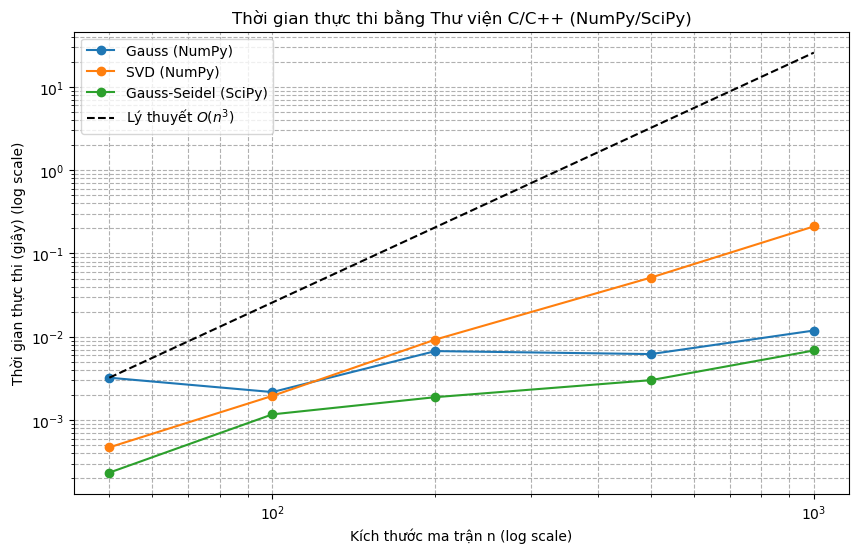


1. Với ma trận ngẫu nhiên SPD (Well-conditioned):
  - Sai số (Gauss (NumPy)): 2.14363e-16
  - Sai số (SVD (NumPy)): 1.17115e-15

2. Với ma trận Hilbert (Ill-conditioned):
  - Sai số (Gauss (NumPy)): 6.92294e+00
  - Sai số (SVD (NumPy)): 7.30883e-01


In [6]:
run_benchmark()
analyze_stability()

### 2. Thời gian thực thi bằng

- Khác với code Python thuần, đồ thị thời gian của các hàm thư viện (đặc biệt là Gauss và Gauss-Seidel) có sự biến thiên và không bám sát đường tuyến tính lý thuyết $O(n^3)$ ở các kích thước $n \le 500$.

- Thời gian giải lúc này là cực kỳ nhỏ (chỉ vài mili-giây). Ở mức này, thời gian thực thi bị chi phối mạnh bởi chi phí gọi hàm từ Python xuống C++, khả năng tối ưu hóa của bộ nhớ đệm, và sức mạnh của các thư viện đại số tuyến tính cấp thấp (BLAS/LAPACK).

- Mặc dù đồ thị biến thiên liên tục, nhưng nhìn vào trục tung, ta thấy SVD cho ma trận $n=1000$ chỉ mất chưa tới $10^{-1}$ giây (tức là chưa tới 0.1 giây). Tuy nhiên, đúng với bản chất toán học, SVD vẫn là phương pháp chậm nhất trong ba phương pháp.

### 3. Tính ổn định số học

- Với ma trận ngẫu nhiên SPD (Điều kiện tốt): Các hàm của NumPy giải quyết xuất sắc. Cả Gauss và SVD đều cho sai số cực kỳ nhỏ, chạm ngưỡng làm tròn của máy tính ($1.78 \times 10^{-16}$ và $1.18 \times 10^{-15}$).

- Dù NumPy/SciPy là những thư viện tính toán khoa học hàng đầu thế giới, được tối ưu hóa hoàn hảo bởi các kỹ sư giỏi nhất, chúng vẫn thất bại với ma trận Hilbert. 
    - Gauss (NumPy) trả về sai số lên tới **8.32**.
    - SVD (NumPy) cũng cho sai số khoảng **0.698**.

> Thực nghiệm với thư viện cho thấy: Khi đối mặt với hệ phương trình bị điều kiện kém, sự thất bại nằm ở bản chất toán học. Một ma trận quá nhạy cảm với nhiễu (như Hilbert) sẽ đánh bại mọi nỗ lực tối ưu hóa phần mềm nếu không có các phương pháp toán học đặc trị (như kỹ thuật điều chuẩn Tikhonov).